In [ ]:
# ---------------------------
# 1. Import necessary packages
# ---------------------------
import pandas as pd
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# ---------------------------
# 2. Load datasets
# ---------------------------
# Paths to files
industry_path = r"E:\00论文\2025江苏人民公社\people's commune_classified2.0.xlsx"
geo_path = r"E:\00论文\2025江苏人民公社\【submit1】heritage science\江苏人民公社整理3.xlsx"

# Read data
df_industry = pd.read_excel(industry_path)
df_geo = pd.read_excel(geo_path)


In [9]:
# 3. One-hot encode the '小类' field
# ---------------------------
grouped = df_industry.groupby("COL_C")["小类"].apply(list).reset_index()

mlb = MultiLabelBinarizer()
industry_vectors = pd.DataFrame(
    mlb.fit_transform(grouped["小类"]),
    columns=mlb.classes_,
    index=grouped["COL_C"]
)


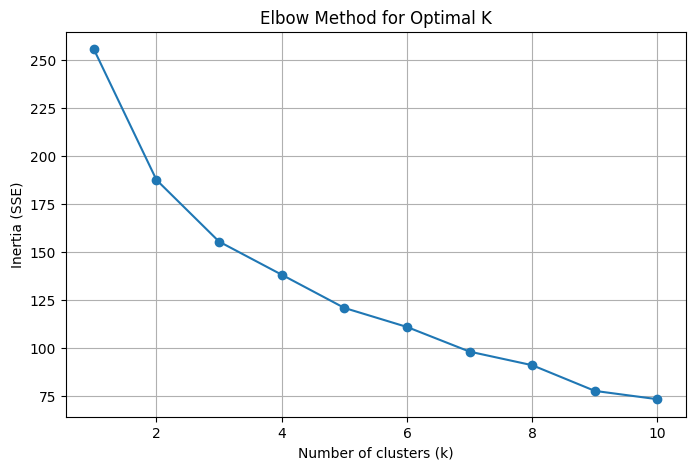

In [10]:
# 4. Elbow method to choose K
# ---------------------------
inertias = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(industry_vectors)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (SSE)")
plt.grid(True)
plt.show()


In [11]:
# 5. KMeans clustering with K=4
# ---------------------------
kmeans = KMeans(n_clusters=4, random_state=42)
grouped["cluster"] = kmeans.fit_predict(industry_vectors)

# Final result table with cluster labels
df_clustered = pd.concat([grouped[["COL_C", "cluster"]], industry_vectors.reset_index(drop=True)], axis=1)

In [12]:
# 6. Merge with geo-coordinates
# ---------------------------
# df_geo["Unnamed: 2"] contains the commune names
df_merged = pd.merge(df_clustered, df_geo, left_on="COL_C", right_on="Unnamed: 2", how="inner")
df_final = df_merged[["COL_C", "cluster", "经度", "纬度"]]  # Longitude/Latitude


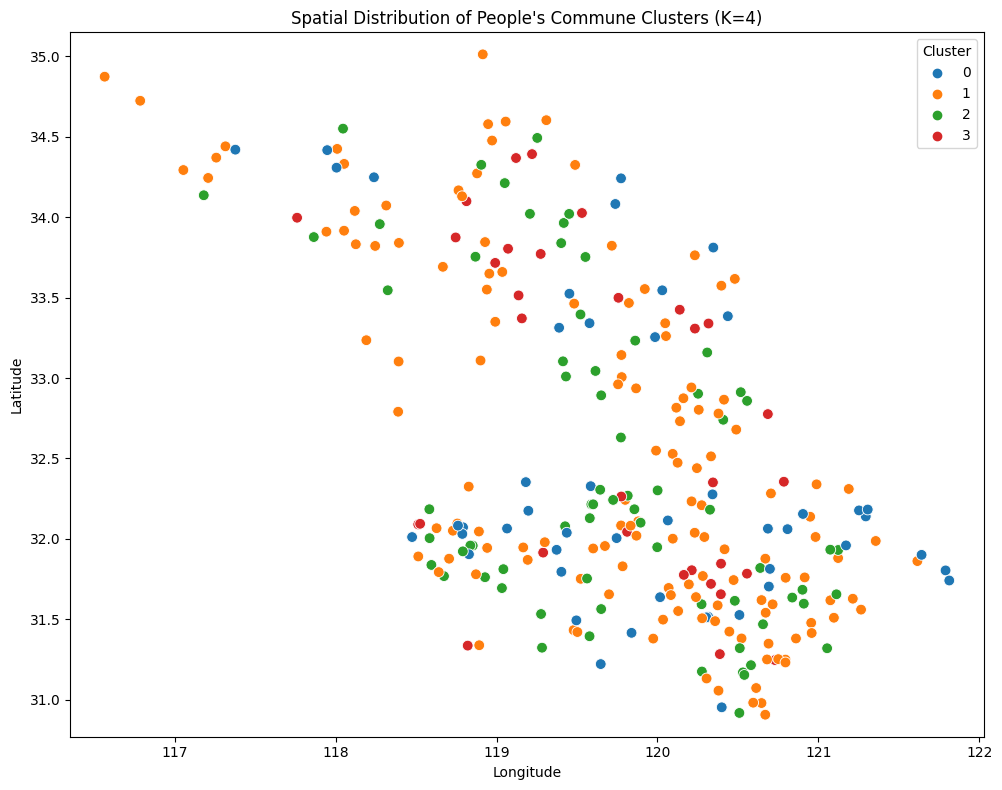

In [13]:
# 7. Plot spatial scatter map
# ---------------------------
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df_final,
    x="经度",
    y="纬度",
    hue="cluster",
    palette="tab10",
    s=60
)
plt.title("Spatial Distribution of People's Commune Clusters (K=4)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Cluster")
plt.axis('equal')
plt.tight_layout()
plt.show()


In [14]:
# ---------------------------
# 8. Output cluster profile (mean industry features per cluster)
# ---------------------------
cluster_profile = df_clustered.drop(columns=["COL_C"]).groupby("cluster").mean()
cluster_profile

,其他,制造业,副业,林业,水利,渔业,电力,畜牧业,种植业
cluster,,,,,,,,,
0,0.413043,0.152174,0.065217,0.195652,0.000000,0.065217,0.043478,0.434783,0.000000
1,0.000000,0.037594,0.000000,0.045113,0.007519,0.052632,0.000000,0.120301,1.000000
2,1.000000,0.187500,0.109375,0.187500,0.078125,0.078125,0.015625,0.000000,1.000000
3,0.766667,0.333333,0.166667,0.333333,0.033333,0.033333,0.033333,1.000000,0.966667


In [15]:
df_final.to_csv(r"E:\00论文\heritage science\0624\commune_clusters_with_coords.csv", index=False)

In [7]:
# ---------------------------
# 1. 导入库
# ---------------------------
import pandas as pd
from sklearn.cluster import KMeans

# ---------------------------
# 2. 读取数据（修改为你的本地路径）
# ---------------------------
file_path = r"E:\people's commune_classified2.0.xlsx"
df_raw = pd.read_excel(file_path)

# ---------------------------
# 3. One-hot 编码小类字段（每行是一个产业小类）
# ---------------------------
df_onehot = pd.get_dummies(df_raw[['COL_C', '小类']], columns=['小类'], prefix='', prefix_sep='')

# ---------------------------
# 4. 按公社聚合（得到每个公社是否有某产业）
# ---------------------------
df_grouped = df_onehot.groupby('COL_C').sum().reset_index()

# ---------------------------
# 5. KMeans 聚类（K=3）
# ---------------------------
kmeans = KMeans(n_clusters=3, random_state=42)
df_grouped['cluster'] = kmeans.fit_predict(df_grouped.drop(columns=['COL_C']))

# ---------------------------
# 6. 输出每个公社的聚类结果
# ---------------------------
df_clustered = df_grouped.copy()

# ---------------------------
# 7. 输出每个类别的产业特征平均值（聚类特征轮廓）
# ---------------------------
cluster_profile = df_clustered.drop(columns=["COL_C"]).groupby("cluster").mean()

# ---------------------------
# 8. 显示结果（在 notebook 中）
# ---------------------------
print("✅ 每个公社的聚类结果：")
print(df_clustered[['COL_C', 'cluster']].head())

print("\n✅ 每类的产业特征表（平均值表示该类内比例）：")
print(cluster_profile)

✅ 每个公社的聚类结果：
  COL_C  cluster
0    丁集        2
1    七都        0
2    三仓        0
3    三余        0
4    三和        0

✅ 每类的产业特征表（平均值表示该类内比例）：
                其他       制造业        副业        林业        水利        渔业  \
cluster                                                                
0         0.523364  0.144860  0.088785  0.135514  0.014019  0.065421   
1         1.907407  0.240741  0.129630  0.388889  0.074074  0.166667   
2        12.200000  1.000000  0.000000  1.200000  0.000000  0.000000   

               电力       畜牧业       种植业  
cluster                                
0        0.009346  0.322430  1.186916  
1        0.037037  0.314815  5.111111  
2        0.000000  0.400000  2.800000  


In [8]:
# 8. Output cluster profile (mean industry features per cluster)
# ---------------------------
cluster_profile = df_clustered.drop(columns=["COL_C"]).groupby("cluster").mean()
cluster_profile

,其他,制造业,副业,林业,水利,渔业,电力,畜牧业,种植业
cluster,,,,,,,,,
0,0.523364,0.144860,0.088785,0.135514,0.014019,0.065421,0.009346,0.322430,1.186916
1,1.907407,0.240741,0.129630,0.388889,0.074074,0.166667,0.037037,0.314815,5.111111
2,12.200000,1.000000,0.000000,1.200000,0.000000,0.000000,0.000000,0.400000,2.800000


In [4]:
# --------------------------
# 1. 导入库
# --------------------------
import pandas as pd
from sklearn.cluster import KMeans

# --------------------------
# 2. 设置路径（根据你本地情况修改）
# --------------------------
file_industry = r"E:\people's commune_classified2.0.xlsx"
file_geo = r"E:\00论文\heritage science\0624\Extract people's commune2.0.csv"

# --------------------------
# 3. 读取数据
# --------------------------
df_industry = pd.read_excel(file_industry)
df_geo = pd.read_csv(file_geo)

# --------------------------
# 4. 小类字段独热编码
# --------------------------
df_onehot = pd.get_dummies(df_industry[['COL_C', '小类']], columns=['小类'], prefix='', prefix_sep='')
df_grouped = df_onehot.groupby('COL_C').sum().reset_index()

# --------------------------
# 5. KMeans 聚类（K=3）
# --------------------------
kmeans = KMeans(n_clusters=3, random_state=42)
df_grouped['cluster'] = kmeans.fit_predict(df_grouped.drop(columns=['COL_C']))

# --------------------------
# 6. 合并地理变量 + 环境变量（保持完整字段）
# --------------------------
df_geo = df_geo.rename(columns={'Commune': 'COL_C'})  # 统一命名
columns_to_keep = [
    'COL_C', 'Longitude', 'Latitude',
    'Elevation', 'Precipitation', 'Temperature', 'Wind',
    'Distance to canal', 'Distance to railway', 'Distance to ocean',
    'Distance to river', 'Distance to highway', 'Distance to central city'
]
df_geo_clean = df_geo[columns_to_keep]

df_merged = pd.merge(df_grouped, df_geo_clean, on='COL_C', how='left')

# --------------------------
# 7. 聚类特征轮廓（只统计小类字段）
# --------------------------
industry_cols = df_grouped.columns.drop(['COL_C', 'cluster'])
cluster_profile = df_merged.groupby('cluster')[industry_cols].mean()

# --------------------------
# 8. 显示结果（或可导出）
# --------------------------
print("✅ 合并后的数据（包含聚类 + 经纬度 + 环境特征）：")
print(df_merged.head())

print("\n✅ 各类公社的主导产业特征（平均值）：")
print(cluster_profile)


# 可选导出结果
df_merged.to_csv(r"E:\00论文\heritage science\0624\cluster_with_location0630.csv", index=False)

✅ 合并后的数据（包含聚类 + 经纬度 + 环境特征）：
  COL_C  其他  制造业  副业  林业  水利  渔业  电力  畜牧业  种植业  ...  Elevation  Precipitation  \
0    丁集  10    2   0   0   0   0   0    1    3  ...         12       0.000034   
1    七都   0    0   0   0   0   0   0    2    0  ...          4       0.000036   
2    三仓   3    2   3   1   0   0   0    1    0  ...          4       0.000047   
3    三余   0    0   0   0   0   0   0    2    0  ...          3       0.000034   
4    三和   0    0   0   0   0   0   0    0    1  ...          5       0.000031   

   Temperature     Wind  Distance to canal  Distance to railway  \
0   286.747986  3.14983           0.087489             0.827591   
1   288.681000  3.92097           0.316898             0.334295   
2   287.307007  3.40743           1.001660             1.195240   
3   287.816986  3.55598           1.008360             0.798021   
4   288.072998  3.24777           0.694642             0.520246   

   Distance to ocean  Distance to river  Distance to highway  \
0           1.044

In [6]:
# ------------------------
# 1. 导入库
# ------------------------
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# ------------------------
# 2. 设置路径
# ------------------------
input_file = r"E:\00论文\heritage science\0624\cluster_with_location0630.csv"
output_file = r"E:\00论文\heritage science\0624\cluster_normalized.csv"

# ------------------------
# 3. 读取数据
# ------------------------
df = pd.read_csv(input_file, encoding="gb18030")

# ------------------------
# 4. 需要归一化的列（请确保列名与文件完全一致）
# ------------------------
columns_to_normalize = [
    'Elevation', 'Precipitation', 'Temperature', 'Wind',
    'Distance to canal', 'Distance to railway', 'Distance to ocean',
    'Distance to river', 'Distance to highway', 'Distance to central city'
]

# ------------------------
# 5. 归一化处理
# ------------------------
scaler = MinMaxScaler()
df[columns_to_normalize] = scaler.fit_transform(df[columns_to_normalize])

# ------------------------
# 6. 保存归一化结果
# ------------------------
df.to_csv(output_file, index=False)
print(f"✅ 已归一化并导出至：{output_file}")


✅ 已归一化并导出至：E:\00论文\heritage science\0624\cluster_normalized.csv


In [9]:
# ------------------------
# 1. 导入库
# ------------------------
import pandas as pd
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.cluster import KMeans

# ------------------------
# 2. 读取原始文件
# ------------------------
file_path = r"E:\people's commune_classified2.0.xlsx"
df = pd.read_excel(file_path)

# ------------------------
# 3. 对公社按小类进行独热编码
# ------------------------
df['小类'] = df['小类'].astype(str)
df_grouped = df.groupby('COL_C')['小类'].apply(list).reset_index()
mlb = MultiLabelBinarizer()
df_encoded = pd.concat([
    df_grouped['COL_C'],
    pd.DataFrame(mlb.fit_transform(df_grouped['小类']), columns=mlb.classes_)
], axis=1)

# ------------------------
# 4. 聚类（K=3，使用高 n_init 提高鲁棒性）
# ------------------------
X = df_encoded.drop(columns=["COL_C"])
kmeans = KMeans(n_clusters=3, init='k-means++', n_init=50, random_state=42)
df_encoded['cluster'] = kmeans.fit_predict(X)

# ------------------------
# 5. 输出各聚类的平均产业特征
# ------------------------
cluster_profile = df_encoded.drop(columns=["COL_C"]).groupby("cluster").mean()
print("✅ 每类公社的平均产业特征：")
print(cluster_profile)

# ------------------------
# 6. 输出每类的样本数量
# ------------------------
print("\n✅ 每类公社的数量分布：")
print(df_encoded['cluster'].value_counts().sort_index())

# （可选）保存结果
output_path = r"E:\people's_commune_clustered_k3.xlsx"
df_encoded.to_excel(output_path, index=False)
print(f"\n✅ 聚类结果已保存至：{output_path}")

✅ 每类公社的平均产业特征：
               其他       制造业        副业        林业        水利        渔业        电力  \
cluster                                                                         
0        0.424242  0.151515  0.121212  0.196970  0.015152  0.060606  0.015152   
1        0.000000  0.069767  0.000000  0.085271  0.007752  0.046512  0.015504   
2        1.000000  0.192308  0.089744  0.166667  0.064103  0.076923  0.012821   

         畜牧业       种植业  
cluster                 
0        1.0  0.681818  
1        0.0  0.906977  
2        0.0  0.820513  

✅ 每类公社的数量分布：
0     66
1    129
2     78
Name: cluster, dtype: int64

✅ 聚类结果已保存至：E:\people's_commune_clustered_k3.xlsx


In [ ]:
# -------------------------------
# 1. 导入库
# -------------------------------
import pandas as pd
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.cluster import KMeans
import numpy as np

# -------------------------------
# 2. 读取数据
# -------------------------------
file_path = r"E:\people's commune_classified2.0.xlsx"
df = pd.read_excel(file_path)

# -------------------------------
# 3. 对小类字段进行独热编码
# -------------------------------
df['小类'] = df['小类'].astype(str)
df_grouped = df.groupby('COL_C')['小类'].apply(list).reset_index()
mlb = MultiLabelBinarizer()
df_encoded = pd.concat([
    df_grouped['COL_C'],
    pd.DataFrame(mlb.fit_transform(df_grouped['小类']), columns=mlb.classes_)
], axis=1)

# -------------------------------
# 4. 准备聚类特征 & 设置初始中心
# -------------------------------
features = df_encoded.drop(columns=['COL_C'])

# 用户定义的三类聚类中心
initial_centers = [
    [1 if col in ['种植业', '畜牧业', '林业'] else 0 for col in features.columns],  # cluster 0: 传统农业型
    [1 if col in ['渔业', '副业'] else 0 for col in features.columns],             # cluster 1: 渔业副业型
    [1 if col in ['制造业', '水利', '电力', '其他', '种植业', '畜牧业'] else 0 for col in features.columns]  # cluster 2: 农工融合型
]

# -------------------------------
# 5. 执行聚类（K=3）
# -------------------------------
kmeans = KMeans(n_clusters=3, init=np.array(initial_centers), n_init=1, max_iter=300, random_state=42)
df_encoded['cluster'] = kmeans.fit_predict(features)

# -------------------------------
# 6. 输出结果
# -------------------------------
# 每类的产业特征均值表格
cluster_profile = df_encoded.drop(columns=['COL_C']).groupby("cluster").mean()
print("✅ 各类产业特征均值表格：")
print(cluster_profile)

# 每类的样本数量
print("\n✅ 每类公社数量分布：")
print(df_encoded['cluster'].value_counts().sort_index())

# 如需保存到本地 CSV，可添加以下语句：
df_encoded.to_csv(r"E:\people's_commune_clustered_k3_2.0.csv", index=False)

✅ 各类产业特征均值表格：
               其他       制造业        副业        林业        水利        渔业        电力  \
cluster                                                                         
0        0.251397  0.027933  0.033520  0.033520  0.027933  0.055866  0.000000   
1        0.413043  0.152174  0.065217  0.195652  0.000000  0.065217  0.043478   
2        0.875000  0.458333  0.125000  0.458333  0.041667  0.062500  0.041667   

              畜牧业       种植业  
cluster                      
0        0.094972  1.000000  
1        0.434783  0.000000  
2        0.604167  0.979167  

✅ 每类公社数量分布：
0    179
1     46
2     48
Name: cluster, dtype: int64


In [15]:
# -----------------------------
# 1. 导入必要库
# -----------------------------
import pandas as pd
import numpy as np
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.cluster import KMeans

# -----------------------------
# 2. 设置文件路径
# -----------------------------
industry_file = r"E:\people's commune_classified2.0.xlsx"
location_file = r"E:\00论文\heritage science\0624\Extract people's commune2.0.csv"
output_file = r"E:\00论文\heritage science\0624\cluster_k4_with_location.csv"

# -----------------------------
# 3. 读取产业数据并处理小类字段
# -----------------------------
df = pd.read_excel(industry_file)
df['小类'] = df['小类'].astype(str)
df_grouped = df.groupby('COL_C')['小类'].apply(list).reset_index()

# -----------------------------
# 4. 独热编码小类字段
# -----------------------------
mlb = MultiLabelBinarizer()
df_encoded = pd.concat([
    df_grouped['COL_C'],
    pd.DataFrame(mlb.fit_transform(df_grouped['小类']), columns=mlb.classes_)
], axis=1)

# -----------------------------
# 5. 定义四类聚类逻辑的初始中心
# -----------------------------
features = df_encoded.drop(columns=['COL_C'])
initial_centers = [
    [1 if col in ['种植业', '畜牧业', '副业'] else 0 for col in features.columns],                          # Cluster 0
    [1 if col in ['渔业', '副业'] else 0 for col in features.columns],                          # Cluster 1
    [1 if col in ['种植业', '制造业', '水利'] else 0 for col in features.columns],                         # Cluster 2
    [1 if col in ['林业', '副业', '电力', '水利'] else 0 for col in features.columns]                      # Cluster 3
]

# -----------------------------
# 6. 执行KMeans聚类
# -----------------------------
kmeans = KMeans(n_clusters=4, init=np.array(initial_centers), n_init=1, max_iter=300, random_state=42)
df_encoded['cluster_k4'] = kmeans.fit_predict(features)
# 每类的产业特征均值表格
cluster_profile = df_encoded.drop(columns=['COL_C']).groupby("cluster_k4").mean()
print("✅ 各类产业特征均值表格：")
print(cluster_profile)

cluster_counts = df_encoded['cluster_k4'].value_counts().sort_index()
print("每类公社数量：")
print(cluster_counts)

# -----------------------------
# 7. 读取经纬度和环境变量数据
# -----------------------------
df_location = pd.read_csv(location_file, encoding='gbk')  # 若出现乱码可尝试 encoding='utf-8'

# -----------------------------
# 8. 合并经纬度数据
# -----------------------------
df_merged = pd.merge(df_encoded, df_location, left_on='COL_C', right_on='Commune', how='left')

# -----------------------------
# 9. 导出结果
# -----------------------------
df_merged.to_csv(output_file, index=False, encoding='utf-8-sig')
print(f"✅ 聚类结果已保存至：{output_file}")

✅ 各类产业特征均值表格：
                  其他  制造业        副业        林业        水利        渔业        电力  \
cluster_k4                                                                    
0           0.312849  0.0  0.033520  0.000000  0.022346  0.055866  0.005587   
1           0.410256  0.0  0.076923  0.230769  0.000000  0.076923  0.051282   
2           0.617647  1.0  0.117647  0.205882  0.058824  0.029412  0.029412   
3           0.619048  0.0  0.095238  1.000000  0.047619  0.095238  0.000000   

                 畜牧业       种植业  
cluster_k4                      
0           0.156425  1.000000  
1           0.512821  0.000000  
2           0.294118  0.764706  
3           0.380952  1.000000  
每类公社数量：
0    179
1     39
2     34
3     21
Name: cluster_k4, dtype: int64


UnicodeDecodeError: 'gbk' codec can't decode byte 0xad in position 472: illegal multibyte sequence

读取数据...
样本数：273，特征维度：9
产业小类：['其他', '制造业', '副业', '林业', '水利', '渔业', '电力', '畜牧业', '种植业']

聚类数量评估指标
  K     Inertia      轮廓系数        CH指数      DB指数
-------------------------------------------------------
  2      187.47    0.3895       98.41    1.4662
  3      155.31    0.4310       87.12    1.2037
  4      138.06    0.4579       76.30    1.4090
  5      120.77    0.4979       74.77    1.2872
  6      110.85    0.5311       69.71    1.2005
  7       98.00    0.5674       71.27    1.2914
  8       90.92    0.5895       68.54    1.1917
-------------------------------------------------------
  轮廓系数最优 K = 8（越大越好）
  CH指数最优   K = 2（越大越好）
  DB指数最优   K = 8（越小越好）



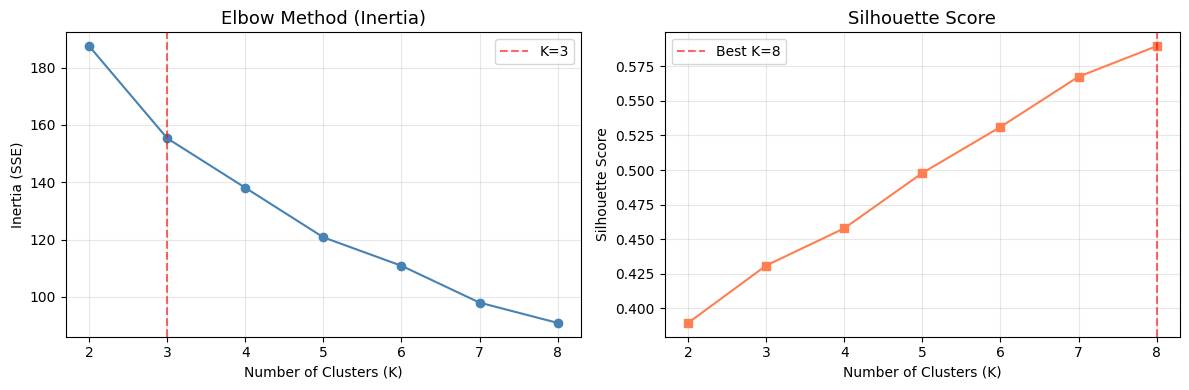

图已保存：cluster_evaluation.png

PCA 主成分分析

各主成分方差解释率：
  PC     方差解释率      累计方差
------------------------------
  PC 1    0.2813    0.2813
  PC 2    0.2160    0.4973
  PC 3    0.1321    0.6294
  PC 4    0.1153    0.7448
  PC 5    0.1095    0.8543
  PC 6    0.0571    0.9114
  PC 7    0.0484    0.9598
  ... (累计已达95%，后续省略)

累计解释80%方差需要：5 个主成分
累计解释90%方差需要：6 个主成分

前3个主成分的因子载荷（各产业小类的权重）：

（只显示|载荷|>0.1的变量）

  PC1（方差解释率=0.2813）：
    其他: +0.8716
    畜牧业: +0.2668
    林业: +0.2623
    制造业: +0.2045
    副业: +0.1589
    种植业: -0.1723

  PC2（方差解释率=0.2160）：
    畜牧业: +0.8018
    其他: -0.3654
    种植业: -0.4607

  PC3（方差解释率=0.1321）：
    林业: +0.1884
    制造业: +0.1313
    畜牧业: -0.5234
    种植业: -0.8145

K=3 时的具体聚类指标（用于论文报告）
  Inertia（SSE）:    155.3143
  轮廓系数:          0.4310
  CH指数:            87.1217
  DB指数:            1.2037
  各类样本数:        {0: 106, 1: 129, 2: 38}

  各类产业特征均值（>0.1的产业）：

  Cluster 0：{'其他': 1.0, '种植业': 0.8113207547169812, '畜牧业': 0.2641509433962264, '林业': 0.2169811320754717, '制造业': 0.19811320754716982

In [2]:
"""
补充分析脚本：回应审稿人 Q10
生成：① 轮廓系数图（补充肘部法则）② PCA参数报告
运行后把输出数字填入审稿人回复

直接在 Jupyter 运行即可
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA

# ══════════════════════════════════════════════
# 配置：修改为你的文件路径
# ══════════════════════════════════════════════
INDUSTRY_FILE = r"E:\00论文\2025江苏人民公社\people's commune_classified2.0.xlsx"

# ══════════════════════════════════════════════
# 1. 读取数据 & One-hot 编码（与原代码一致）
# ══════════════════════════════════════════════
print("读取数据...")
df = pd.read_excel(INDUSTRY_FILE)
df['小类'] = df['小类'].astype(str)
df_grouped = df.groupby('COL_C')['小类'].apply(list).reset_index()

mlb = MultiLabelBinarizer()
features = pd.DataFrame(
    mlb.fit_transform(df_grouped['小类']),
    columns=mlb.classes_,
    index=df_grouped['COL_C']
)
print(f"样本数：{len(features)}，特征维度：{features.shape[1]}")
print(f"产业小类：{list(features.columns)}\n")

# ══════════════════════════════════════════════
# 2. 计算多种聚类评估指标（K=2到8）
# ══════════════════════════════════════════════
print("=" * 55)
print("聚类数量评估指标")
print("=" * 55)
print(f"{'K':>3}  {'Inertia':>10}  {'轮廓系数':>8}  {'CH指数':>10}  {'DB指数':>8}")
print("-" * 55)

inertias    = []
silhouettes = []
ch_scores   = []
db_scores   = []
k_range     = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(features)
    
    inertia = km.inertia_
    sil     = silhouette_score(features, labels)
    ch      = calinski_harabasz_score(features, labels)
    db      = davies_bouldin_score(features, labels)
    
    inertias.append(inertia)
    silhouettes.append(sil)
    ch_scores.append(ch)
    db_scores.append(db)
    
    print(f"  {k}  {inertia:>10.2f}  {sil:>8.4f}  {ch:>10.2f}  {db:>8.4f}")

print("-" * 55)
best_k_sil = list(k_range)[silhouettes.index(max(silhouettes))]
best_k_ch  = list(k_range)[ch_scores.index(max(ch_scores))]
best_k_db  = list(k_range)[db_scores.index(min(db_scores))]
print(f"  轮廓系数最优 K = {best_k_sil}（越大越好）")
print(f"  CH指数最优   K = {best_k_ch}（越大越好）")
print(f"  DB指数最优   K = {best_k_db}（越小越好）\n")

# ══════════════════════════════════════════════
# 3. 画图：肘部法则 + 轮廓系数（并排）
# ══════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(k_range), inertias, marker='o', color='steelblue')
axes[0].set_title("Elbow Method (Inertia)", fontsize=13)
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Inertia (SSE)")
axes[0].axvline(x=3, color='red', linestyle='--', alpha=0.6, label='K=3')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(k_range), silhouettes, marker='s', color='coral')
axes[1].set_title("Silhouette Score", fontsize=13)
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Silhouette Score")
axes[1].axvline(x=best_k_sil, color='red', linestyle='--', alpha=0.6, label=f'Best K={best_k_sil}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("cluster_evaluation.png", dpi=150, bbox_inches='tight')
plt.show()
print("图已保存：cluster_evaluation.png\n")

# ══════════════════════════════════════════════
# 4. PCA 分析（你原代码import了但没用，这里补充报告）
# ══════════════════════════════════════════════
print("=" * 55)
print("PCA 主成分分析")
print("=" * 55)

pca_full = PCA(random_state=42)
pca_full.fit(features)

print(f"\n各主成分方差解释率：")
print(f"{'PC':>4}  {'方差解释率':>8}  {'累计方差':>8}")
print("-" * 30)
cumvar = 0
n_components_80 = None
n_components_90 = None
for i, var in enumerate(pca_full.explained_variance_ratio_):
    cumvar += var
    print(f"  PC{i+1:>2}  {var:>8.4f}  {cumvar:>8.4f}")
    if n_components_80 is None and cumvar >= 0.80:
        n_components_80 = i + 1
    if n_components_90 is None and cumvar >= 0.90:
        n_components_90 = i + 1
    if cumvar >= 0.95:
        print(f"  ... (累计已达95%，后续省略)")
        break

print(f"\n累计解释80%方差需要：{n_components_80} 个主成分")
print(f"累计解释90%方差需要：{n_components_90} 个主成分")

# 输出前3个主成分的载荷（各产业贡献）
print(f"\n前3个主成分的因子载荷（各产业小类的权重）：")
loadings = pd.DataFrame(
    pca_full.components_[:3].T,
    index=features.columns,
    columns=['PC1', 'PC2', 'PC3']
).round(4)

# 只显示载荷绝对值>0.1的
print("\n（只显示|载荷|>0.1的变量）")
for pc in ['PC1', 'PC2', 'PC3']:
    sig = loadings[loadings[pc].abs() > 0.1][pc].sort_values(ascending=False)
    print(f"\n  {pc}（方差解释率={pca_full.explained_variance_ratio_[int(pc[2])-1]:.4f}）：")
    for var, val in sig.items():
        print(f"    {var}: {val:+.4f}")

# ══════════════════════════════════════════════
# 5. 最终选定K=3时的具体指标（用于论文报告）
# ══════════════════════════════════════════════
print("\n" + "=" * 55)
print("K=3 时的具体聚类指标（用于论文报告）")
print("=" * 55)
km3 = KMeans(n_clusters=3, random_state=42, n_init=10)
labels3 = km3.fit_predict(features)
print(f"  Inertia（SSE）:    {km3.inertia_:.4f}")
print(f"  轮廓系数:          {silhouette_score(features, labels3):.4f}")
print(f"  CH指数:            {calinski_harabasz_score(features, labels3):.4f}")
print(f"  DB指数:            {davies_bouldin_score(features, labels3):.4f}")
print(f"  各类样本数:        {dict(zip(*np.unique(labels3, return_counts=True)))}")

# 各类产业均值
cluster_profile = pd.DataFrame(features.values, columns=features.columns)
cluster_profile['cluster'] = labels3
print("\n  各类产业特征均值（>0.1的产业）：")
profile_mean = cluster_profile.groupby('cluster').mean()
for c in range(3):
    sig_features = profile_mean.loc[c][profile_mean.loc[c] > 0.1].sort_values(ascending=False)
    print(f"\n  Cluster {c}：{sig_features.to_dict()}")


In [1]:
"""
Q2 补充分析脚本：PCA 载荷表（针对9维产业小类矩阵）
运行环境：VSCode / 本地 Python
输出：pca_loadings_report.xlsx（载荷表 + 方差解释率）
"""

import pandas as pd
import numpy as np
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.decomposition import PCA

# ══════════════════════════════════════════════
# 配置：改成你本地实际路径
# ══════════════════════════════════════════════
INDUSTRY_FILE = r"E:\00论文\2025江苏人民公社\people's commune_classified2.0.xlsx"
OUTPUT_FILE = r"pca_loadings_report.xlsx"
VARIANCE_THRESHOLD = 0.85  # 对应论文里写的 85%

# ══════════════════════════════════════════════
# 1. 读取数据 & One-hot 编码（与原代码一致）
# ══════════════════════════════════════════════
print("读取数据...")
df = pd.read_excel(INDUSTRY_FILE)
df['小类'] = df['小类'].astype(str)
df_grouped = df.groupby('COL_C')['小类'].apply(list).reset_index()

mlb = MultiLabelBinarizer()
features = pd.DataFrame(
    mlb.fit_transform(df_grouped['小类']),
    columns=mlb.classes_,
    index=df_grouped['COL_C']
)
print(f"样本数：{len(features)}，特征维度（产业小类数）：{features.shape[1]}")
print(f"产业小类：{list(features.columns)}\n")

# ══════════════════════════════════════════════
# 2. PCA 全量分解
# ══════════════════════════════════════════════
pca_full = PCA(random_state=42)
pca_full.fit(features)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)

# 按论文写的 85% 阈值确定保留的主成分数
n_components_85 = int(np.argmax(cumvar >= VARIANCE_THRESHOLD) + 1)
print(f"按累计方差解释率 ≥ {VARIANCE_THRESHOLD*100:.0f}% 的标准，需保留 {n_components_85} 个主成分\n")

# 方差解释率表
variance_df = pd.DataFrame({
    "Component": [f"PC{i+1}" for i in range(len(pca_full.explained_variance_ratio_))],
    "Explained_Variance_Ratio": pca_full.explained_variance_ratio_.round(4),
    "Cumulative_Variance": cumvar.round(4),
})
print("各主成分方差解释率：")
print(variance_df.to_string(index=False))
print()

# ══════════════════════════════════════════════
# 3. 输出保留主成分的完整载荷表（不再写死3个）
# ══════════════════════════════════════════════
loadings_85 = pd.DataFrame(
    pca_full.components_[:n_components_85].T,
    index=features.columns,
    columns=[f'PC{i+1}' for i in range(n_components_85)]
).round(4)

print(f"保留的 {n_components_85} 个主成分的完整载荷表：")
print(loadings_85.to_string())
print()

# 每个主成分上，按载荷绝对值排序，列出贡献最大的变量（方便你写正文解读段落）
print("每个主成分的主导变量（|载荷| 从大到小排序）：")
for pc in loadings_85.columns:
    sig = loadings_85[pc].abs().sort_values(ascending=False)
    top_vars = sig.head(5)
    print(f"\n  {pc}（方差解释率={pca_full.explained_variance_ratio_[int(pc[2:])-1]:.4f}）：")
    for var in top_vars.index:
        print(f"    {var}: {loadings_85.loc[var, pc]:+.4f}")

# ══════════════════════════════════════════════
# 4. 导出到 Excel（可直接整理为 Supplementary Table）
# ══════════════════════════════════════════════
with pd.ExcelWriter(OUTPUT_FILE, engine="openpyxl") as writer:
    variance_df.to_excel(writer, sheet_name="Variance_Explained", index=False)
    loadings_85.to_excel(writer, sheet_name="PCA_Loadings")

print(f"\n结果已写入：{OUTPUT_FILE}")
print("  Sheet「Variance_Explained」：各主成分方差解释率 + 累计方差")
print(f"  Sheet「PCA_Loadings」：保留的 {n_components_85} 个主成分的完整载荷表")

读取数据...
样本数：273，特征维度（产业小类数）：9
产业小类：['其他', '制造业', '副业', '林业', '水利', '渔业', '电力', '畜牧业', '种植业']

按累计方差解释率 ≥ 85% 的标准，需保留 5 个主成分

各主成分方差解释率：
Component  Explained_Variance_Ratio  Cumulative_Variance
      PC1                    0.2813               0.2813
      PC2                    0.2160               0.4973
      PC3                    0.1321               0.6294
      PC4                    0.1153               0.7448
      PC5                    0.1095               0.8543
      PC6                    0.0571               0.9114
      PC7                    0.0484               0.9598
      PC8                    0.0261               0.9860
      PC9                    0.0140               1.0000

保留的 5 个主成分的完整载荷表：
        PC1     PC2     PC3     PC4     PC5
其他   0.8716 -0.3654 -0.0821 -0.1957 -0.2193
制造业  0.2045 -0.0073  0.1313 -0.1714  0.9480
副业   0.1589  0.0454 -0.0344  0.0972  0.0349
林业   0.2623  0.0824  0.1884  0.9128  0.0947
水利   0.0412 -0.0481 -0.0252 -0.0195  0.0246
渔业   0.0418